# Análisis exploratorio de datos sobre exoplanetas

## Equipo 5 - Planetas análogos

* Cristóbal Castro Riquelme
* Catalina Echeverría
* Vanessa Meza
* Antonia Morales



Al inicio del notebook deben explicar brevemente:
* cuál es el enfoque de análisis de su grupo
* cuál es el objetivo específico de su trabajo
* qué variables consideran más relevantes para abordar su tema.

Contexto: El Planetary Habitability Laboratory de la Universidad de Arecibo, en colaboración con datos de la NASA (misiones Kepler y TESS), mantiene un catálogo con métricas cuantitativas que intentan sistematizar qué tan parecido a la Tierra podría ser un planeta detectado.
Trabajarán con un subconjunto del Habitable Worlds Catalog (HWC), un catálogo que reúne propiedades planetarias, estelares e índices derivados relacionados con habitabilidad potencial.
La habitabilidad no es una propiedad simple ni única. Distintas perspectivas científicas pueden priorizar candidatos distintos. Por eso, cada equipo abordará el problema desde un enfoque diferente.

Desde el descubrimiento del primer exoplaneta en el año 1992, en el imaginario colectivo se ha instalado una interrogante que ha tomado protagonismo en la astronomía contemporánea: ¿existe vida en otros planetas? Para resolver esta pregunta, la astronomía se ha ocupado, en las últimas tres décadas, de avanzar en nuevas teorías y tecnologías para hacer avances cada vez mayores en la pesquisa de nuevos exoplanetas que podrían albergar vida extraterrestre.

En este contexto, el saber cómo trabajar y analizar los numerosos datos disponibles es crucial...

En el presente trabajo, se utilizarán datos del Habitable Worlds Catalog (HWC), diseñado por El Planetary Habitability Laboratory de la Universidad de Puerto Rico. En particular, nuestro grupo se enfocará en buscar planetas que exhiban similitudes físicas a la Tierra, a través del uso del índice ESI (Earth Similarity Index).

* Pregunta guía: ¿Qué tan raros son los planetas tipo Tierra en el catálogo? El foco está en comparar sistemáticamente los
planetas del dataset con los valores de referencia de la Tierra, identificar cuántos se parecen realmente y entender en qué variables el catálogo se aleja más de nuestro planeta.
* Misión específica: Identificar candidatos que se acerquen a la Tierra en tamaño, masa, densidad y condiciones energéticas, y defender qué tan razonable es usar “similitud terrestre” como criterio de priorización.

## 2. Inspección y preparación de los datos

In [3]:
#Importamos las librerías a usar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
#Cargamos los datos

df = pd.read_csv("hwc.csv")
df.set_index("P_NAME", inplace=True)
#Devolvemos los primeros cinco valores de la tabla para tener una visión general
df.head()

,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,P_RADIUS,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
P_NAME,,,,,,,,,,,,,,,,,,,,,
OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,13.90,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,2.90,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,2.11,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,3.52,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,2.07,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [12]:
df

,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,P_RADIUS,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
P_NAME,,,,,,,,,,,,,,,,,,,,,
OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00000,-120.00000,413.00000,0,Mass,13.90,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60000,-3.60000,4.40000,0,Mass,2.90,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10000,NaN,NaN,0,M-R relationship,2.11,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
K2-283 b,Transit,K2,2018,2019-09-05,12.20000,NaN,NaN,0,M-R relationship,3.52,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94000,NaN,NaN,0,M-R relationship,2.07,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HD 222155 b,Radial Velocity,Haute-Provence Observatory,2011,2023-06-12,581.62598,-82.63539,111.23994,0,Mass,13.40,...,1.893917,0.541322,0,0,Cold,0,0.178593,Andromeda,And,Andromeda
HD 88986 b,Radial Velocity,Haute-Provence Observatory,2023,2023-12-04,17.20000,-3.80000,4.00000,0,Mass,2.49,...,2.520276,0.543834,0,0,Hot,0,0.379540,Leo Minor,LMi,Little Lion
Kepler-30 b,Transit,Kepler,2012,2023-11-28,11.30000,-1.40000,1.40000,0,Mass,3.90,...,1.249824,0.400198,0,0,Hot,0,0.241771,Lyra,Lyr,Lyre


In [ ]:
#Reemplazar nan
df_detec = df["P_DETECTION"]
df_de_Micro = df.isin("Microlensing")


In [5]:
#Limpiamos los datos de interés
clean_df = df[["P_MASS", "P_DENSITY", "P_RADIUS", "P_FLUX", "P_ESI", "P_HABITABLE", "P_TEMP_SURF"]].dropna()
clean_mass = clean_df["P_MASS"]
clean_density = clean_df["P_DENSITY"]
clean_radius = clean_df["P_RADIUS"]
clean_flux = clean_df["P_FLUX"]
clean_esi = clean_df["P_ESI"]
clean_temp = clean_df["P_TEMP_SURF"]

clean_df

,P_MASS,P_DENSITY,P_RADIUS,P_FLUX,P_ESI,P_HABITABLE,P_TEMP_SURF
P_NAME,,,,,,,
Kepler-829 b,5.100,0.542904,2.110,238.528680,0.254763,0,1130.60440
Kepler-477 b,4.940,0.556950,2.070,51.163853,0.276721,0,769.42507
TOI-238 b,3.400,1.233772,1.402,766.125920,0.284877,0,1504.26870
TOI-1470 b,7.320,0.706548,2.180,48.505343,0.272496,0,746.01801
HD 86226 c,7.250,0.719410,2.160,492.983910,0.249443,0,1354.17430
...,...,...,...,...,...,...,...
Kepler-1834 b,2.730,0.879016,1.459,107.655610,0.293471,0,926.69044
Kepler-1869 c,0.330,0.814364,0.740,1136.799700,0.286272,0,1670.50010
Kepler-290 d,0.566,0.889859,0.860,1093.852000,0.292181,0,1654.49390


In [6]:
#Nuestra intención inicial era filtrar los datos para no considerar supertierras y poder manejar datos de nuestro interés,
#sin embargo, por falta de tiempo hemos terminado utilizando el DataFrame limpio.
selection_mass = clean_df[clean_df["P_MASS"] <= 5]
selection_esi = selection_mass[selection_mass["P_ESI"] >= 0.5]
selection_esi


,P_MASS,P_DENSITY,P_RADIUS,P_FLUX,P_ESI,P_HABITABLE,P_TEMP_SURF
P_NAME,,,,,,,
GJ 357 c,3.40,0.743284,1.660,4.278981,0.527043,0,413.77153
L 98-59 d,2.31,0.585653,1.580,4.402496,0.527143,0,416.72568
TOI-270 d,4.78,0.492556,2.133,3.735527,0.518092,0,399.88037
L 98-59 e,3.06,0.806023,1.560,2.210797,0.691733,0,349.71904
GJ 1132 c,2.64,0.902809,1.430,2.005501,0.732382,0,337.56210
...,...,...,...,...,...,...,...
Ross 508 b,4.00,0.652690,1.830,1.320491,0.770771,2,301.85915
Wolf 1069 b,1.26,1.000229,1.080,0.652021,0.848593,1,258.51806
Kepler-1126 b,3.64,0.703013,1.730,4.676722,0.504522,0,423.06871


In [7]:
#La cantidad de datos con la que teníamos la intención de trabajar
len (selection_esi[selection_esi["P_HABITABLE"] > 0])

40

## 3. Análisis exploratorio de datos y 4. Discusión e interpretación
Realizamos tres scatter plots comparativos según distintos parámetros y como se relacionan según los valores de la Tierra.

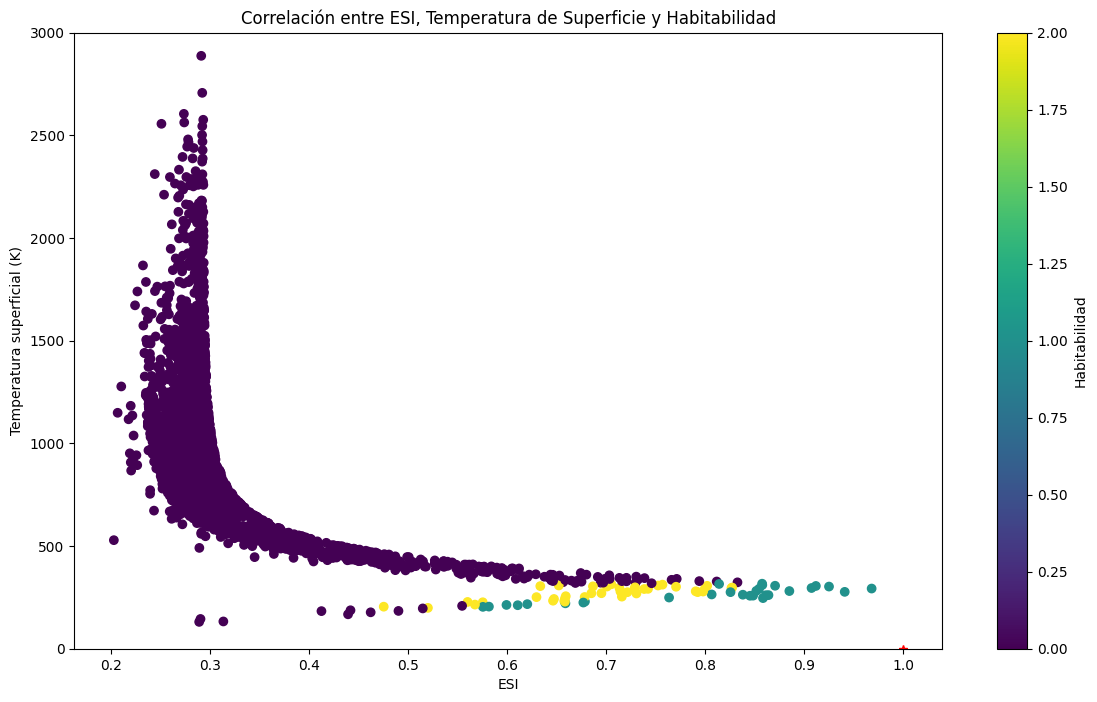

In [8]:
#Gráfico donde comparamos los planetas según ESI y Temperatura Superficial, coloreando según la habitabilidad.
plt.figure(figsize = (14,8))
scatter_plot = plt.scatter(clean_df["P_ESI"], clean_df["P_TEMP_SURF"], c=clean_df["P_HABITABLE"])
plt.colorbar(scatter_plot, label="Habitabilidad")
plt.plot(1, 1, color="red", marker="*")
plt.xlabel("ESI")
plt.ylabel("Temperatura superficial (K)")
plt.title("Correlación entre ESI, Temperatura de Superficie y Habitabilidad")
plt.ylim(0, 3000)
plt.show()

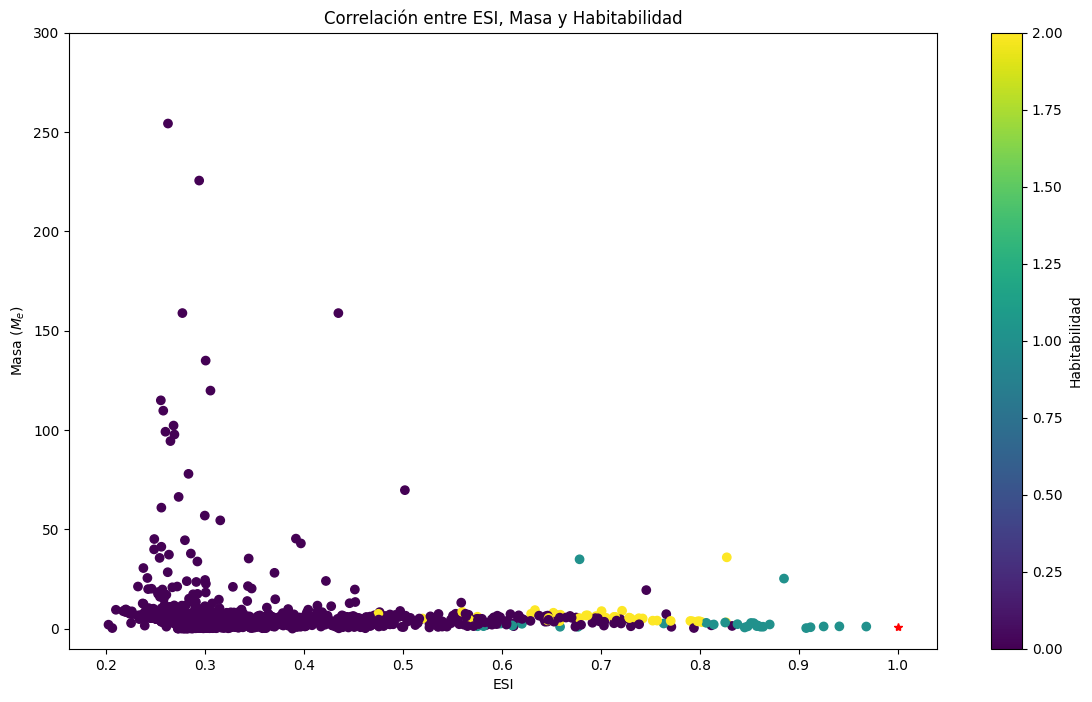

In [9]:
#Gráfico donde comparamos los planetas según ESI y Masa, coloreando según la habitabilidad.
plt.figure(figsize = (14,8))
scatter_plot = plt.scatter(clean_df["P_ESI"], clean_df["P_MASS"], c=clean_df["P_HABITABLE"])
plt.colorbar(scatter_plot, label="Habitabilidad")
plt.plot(1, 1, color="red", marker="*")
plt.xlabel("ESI")
plt.ylabel(r"Masa $(M_e)$")
plt.title("Correlación entre ESI, Masa y Habitabilidad")
plt.ylim(-10, 300)
plt.show()

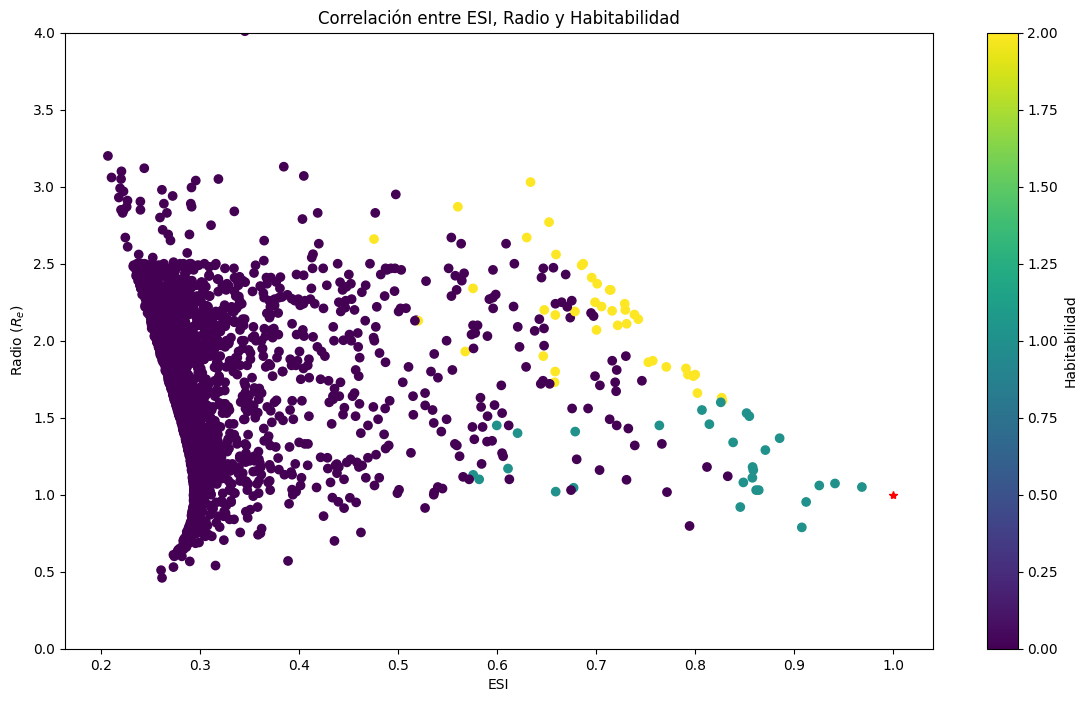

In [10]:
#Gráfico donde comparamos los planetas según ESI y Radio, coloreando según la habitabilidad.
plt.figure(figsize = (14,8))
scatter_plot = plt.scatter(clean_df["P_ESI"], clean_df["P_RADIUS"], c=clean_df["P_HABITABLE"])
plt.colorbar(scatter_plot, label="Habitabilidad")
plt.plot(1, 1, color="red", marker="*")
plt.xlabel("ESI")
plt.ylabel(r"Radio $(R_e)$")
plt.title("Correlación entre ESI, Radio y Habitabilidad")
plt.ylim(0,4)
plt.show()

## 5. Selección de candidatos
Finalmente, ordenamos los valores según mayor ESI a menor y escogemos los primeros tres, ya que nos concentramos únicamente en relaciones físicas muy similares a la Tierra, más no implica que sean automáticamente apropiados para la habitabilidad.
Es por esto que consideramos que la selección de planetas mediante este método es ineficiente y requiere de más métodos acompañantes.

In [11]:
sort_df = clean_df.sort_values("P_ESI", ascending = False)
sort_df.head(3)

,P_MASS,P_DENSITY,P_RADIUS,P_FLUX,P_ESI,P_HABITABLE,P_TEMP_SURF
P_NAME,,,,,,,
Teegarden's Star b,1.16,1.002052,1.050,1.077943,0.968362,1,293.09014
TOI-700 d,1.25,1.011838,1.073,0.859827,0.941176,1,276.93926
Kepler-1649 c,1.20,1.007543,1.060,1.226057,0.925298,1,302.72840


## 6. Conclusiones